#  Smart City Traffic – Exploratory Data Analysis

**Smart City Traffic Pattern Forecasting**

This notebook explores the traffic dataset to understand:
- Overall traffic distribution
- Patterns per junction
- Peak hours and rush periods
- Weekday vs weekend differences
- Holiday effects
- Seasonal trends

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, '../src')
from data_preprocessing import load_data, clean_data
from feature_engineering import extract_features

sns.set_theme(style='darkgrid', palette='Blues_d')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 14

print('Libraries loaded ')

Libraries loaded 


## 1. Load & Clean Data

In [2]:
df_raw   = load_data('../data/raw/traffic_data.csv')
df_clean = clean_data(df_raw)
df       = extract_features(df_clean)

print(f'Shape: {df.shape}')
df.head()

✅ Loaded data: 48,204 rows × 8 columns
No DateTime column found. Creating synthetic DateTime.
  Dropped 0 duplicate rows.
✅ Cleaned data: 48,204 rows remaining.
 Features extracted. Total columns: 28
Shape: (48204, 28)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,Rush Hour,Vehicles,DateTime,Junction,...,IsHoliday,IsRushHour,IsPeakSeason,Sin_Hour,Cos_Hour,Sin_Month,Cos_Month,Sin_DayOfWeek,Cos_DayOfWeek,Junction_1
0,NaN,288.28,0.0,0.0,40,Clouds,1,5545,2016-01-01 00:00:00,1,...,1,0,0,0.000000,1.000000,0.5,0.866025,-0.433884,-0.900969,1
1,NaN,289.36,0.0,0.0,75,Clouds,0,4516,2016-01-01 01:00:00,1,...,1,0,0,0.258819,0.965926,0.5,0.866025,-0.433884,-0.900969,1
2,NaN,289.58,0.0,0.0,90,Clouds,0,4767,2016-01-01 02:00:00,1,...,1,0,0,0.500000,0.866025,0.5,0.866025,-0.433884,-0.900969,1
3,NaN,290.13,0.0,0.0,90,Clouds,0,5026,2016-01-01 03:00:00,1,...,1,0,0,0.707107,0.707107,0.5,0.866025,-0.433884,-0.900969,1
4,NaN,291.14,0.0,0.0,75,Clouds,0,4918,2016-01-01 04:00:00,1,...,1,0,0,0.866025,0.500000,0.5,0.866025,-0.433884,-0.900969,1


## 2. Basic Statistics

In [3]:
print('=== Overall Vehicle Statistics ===')
print(df['Vehicles'].describe().to_string())

print('\n=== By Junction ===')
df.groupby('Junction')['Vehicles'].describe().round(2)

=== Overall Vehicle Statistics ===
count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000

=== By Junction ===


,count,mean,std,min,25%,50%,75%,max
Junction,,,,,,,,
1,48204.0,3259.82,1986.86,0.0,1193.0,3380.0,4933.0,7280.0


## 3. Traffic Volume by Junction

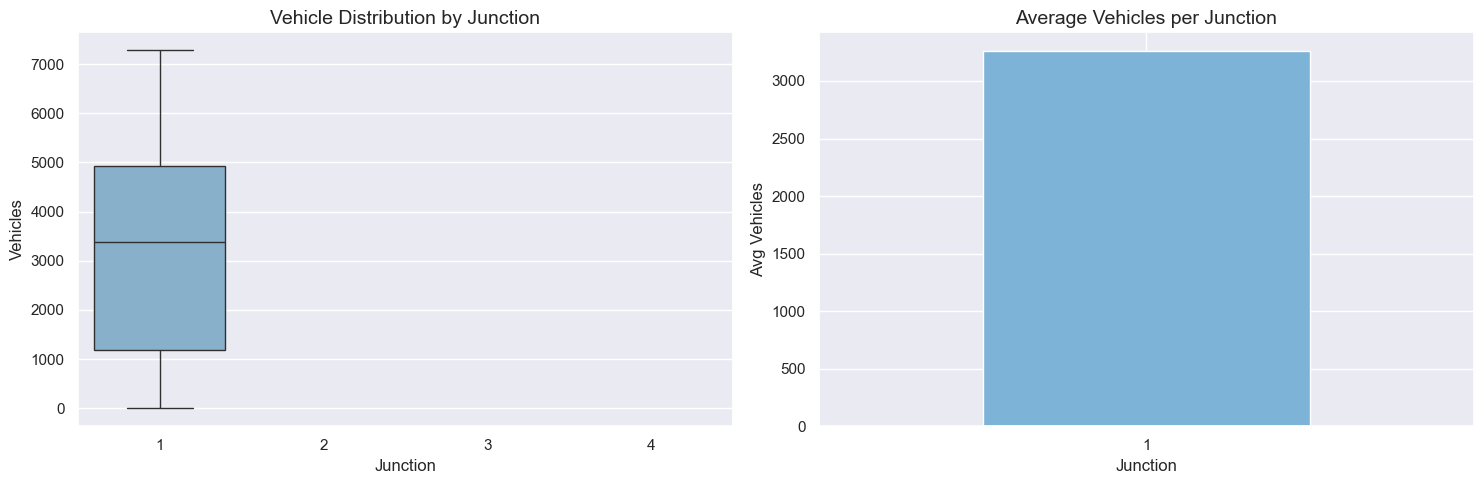

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
junc_order = [1, 2, 3, 4]
sns.boxplot(data=df, x='Junction', y='Vehicles', palette='Blues_d',
            order=junc_order, ax=axes[0])
axes[0].set_title('Vehicle Distribution by Junction')

# Mean bar
df.groupby('Junction')['Vehicles'].mean().plot(
    kind='bar', color=sns.color_palette('Blues_d', 4),
    ax=axes[1], edgecolor='white'
)
axes[1].set_title('Average Vehicles per Junction')
axes[1].set_xlabel('Junction')
axes[1].set_ylabel('Avg Vehicles')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../results/graphs/junction_distribution.png', dpi=150)
plt.show()

## 4. Hourly Traffic Patterns

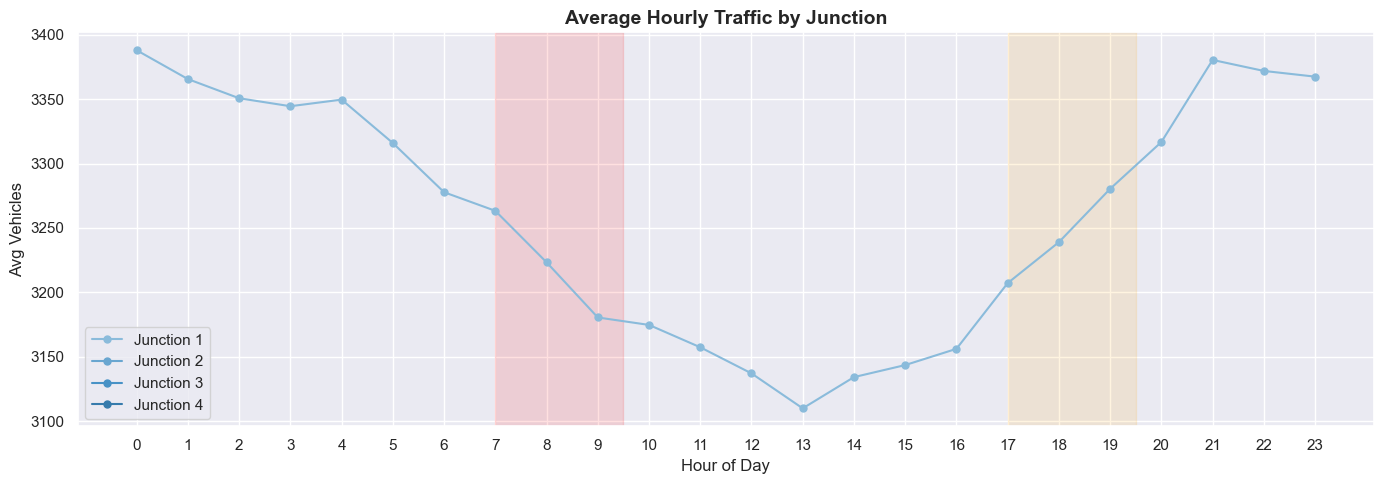


Peak hours per junction:


Junction
1    (1, 0)
Name: Vehicles, dtype: object

In [ ]:
hourly = df.groupby(['Hour', 'Junction'])['Vehicles'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for jn in [1, 2, 3, 4]:
    sub = hourly[hourly['Junction'] == jn]
    ax.plot(sub['Hour'], sub['Vehicles'], marker='o', ms=5, label=f'Junction {jn}')

ax.set_title('Average Hourly Traffic by Junction', fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Vehicles')
ax.set_xticks(range(0, 24))
ax.legend()
ax.axvspan(7, 9.5, alpha=0.12, color='red', label='Morning Rush')
ax.axvspan(17, 19.5, alpha=0.12, color='orange', label='Evening Rush')

plt.tight_layout()
plt.savefig('../results/graphs/hourly_traffic.png', dpi=150)
plt.show()

print('\nPeak hours per junction:')
df.groupby(['Junction','Hour'])['Vehicles'].mean().groupby('Junction').idxmax()

## 5. Weekday vs Weekend

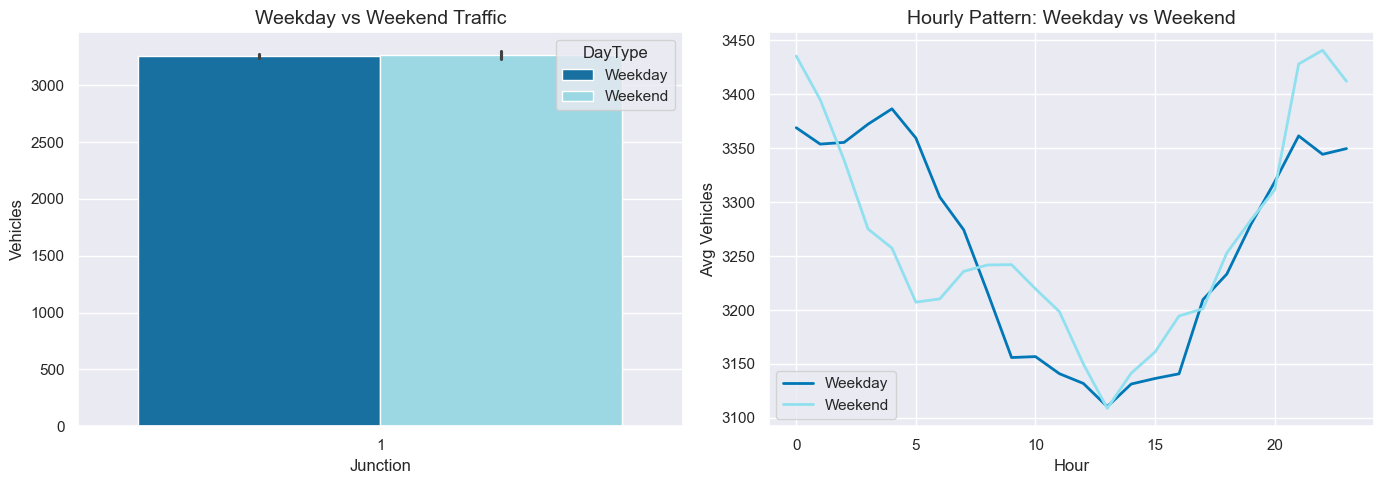

In [ ]:
df['DayType'] = df['IsWeekend'].map({0: 'Weekday', 1: 'Weekend'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='Junction', y='Vehicles', hue='DayType',
            palette=['#0077B6', '#90E0EF'], ax=axes[0])
axes[0].set_title('Weekday vs Weekend Traffic')

# Hour-by-hour comparison (all junctions)
wk = df.groupby(['Hour', 'DayType'])['Vehicles'].mean().reset_index()
for dt, col in [('Weekday', '#0077B6'), ('Weekend', '#90E0EF')]:
    sub = wk[wk['DayType'] == dt]
    axes[1].plot(sub['Hour'], sub['Vehicles'], label=dt, color=col, lw=2)
axes[1].set_title('Hourly Pattern: Weekday vs Weekend')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Avg Vehicles')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/graphs/weekday_vs_weekend.png', dpi=150)
plt.show()

## 6. Monthly & Seasonal Trends

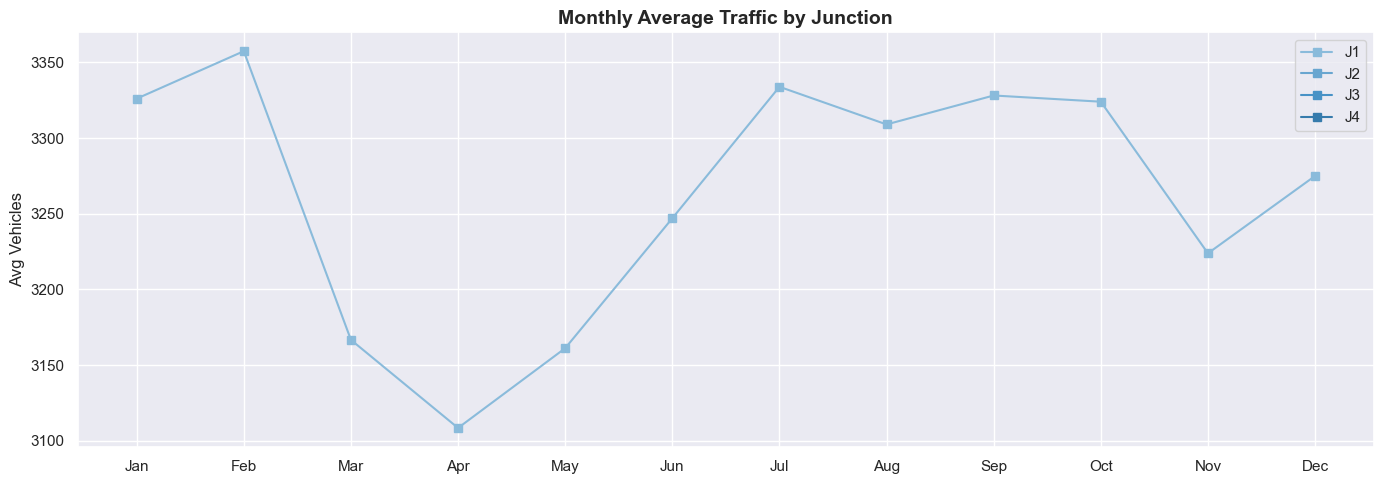

In [ ]:
monthly = df.groupby(['Month', 'Junction'])['Vehicles'].mean().reset_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 5))
for jn in [1, 2, 3, 4]:
    sub = monthly[monthly['Junction'] == jn]
    ax.plot(sub['Month'], sub['Vehicles'], marker='s', ms=6, label=f'J{jn}')

ax.set_title('Monthly Average Traffic by Junction', fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel('Avg Vehicles')
ax.legend()

plt.tight_layout()
plt.savefig('../results/graphs/monthly_trend.png', dpi=150)
plt.show()

## 7. Holiday vs Normal Day Analysis

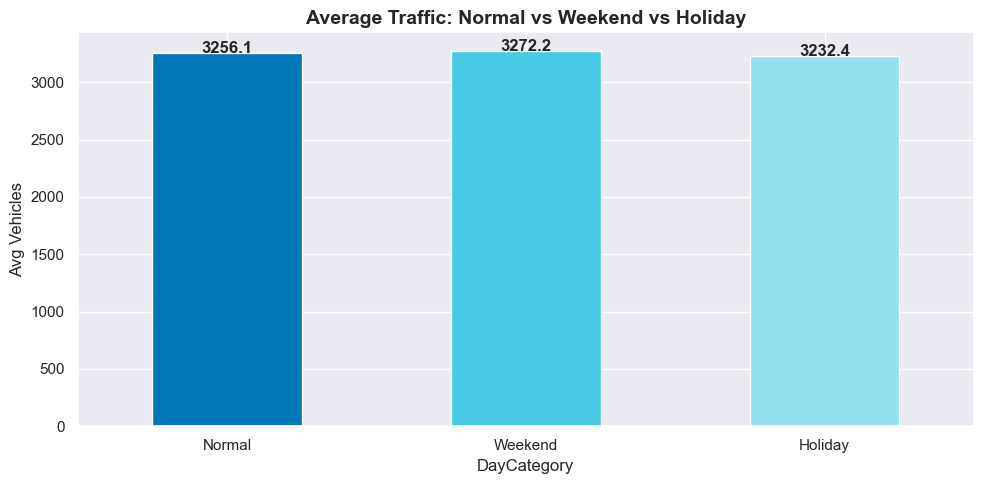

In [ ]:
df['DayCategory'] = 'Normal'
df.loc[df['IsHoliday'] == 1, 'DayCategory'] = 'Holiday'
df.loc[(df['IsWeekend'] == 1) & (df['IsHoliday'] == 0), 'DayCategory'] = 'Weekend'

fig, ax = plt.subplots(figsize=(10, 5))
cat_order = ['Normal', 'Weekend', 'Holiday']
colors    = ['#0077B6', '#48CAE4', '#90E0EF']

means = df.groupby('DayCategory')['Vehicles'].mean().reindex(cat_order)
means.plot(kind='bar', color=colors, edgecolor='white', ax=ax)

ax.set_title('Average Traffic: Normal vs Weekend vs Holiday', fontweight='bold')
ax.set_ylabel('Avg Vehicles')
ax.tick_params(axis='x', rotation=0)

for i, v in enumerate(means):
    ax.text(i, v + 0.5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/graphs/holiday_analysis.png', dpi=150)
plt.show()

## 8. Correlation Heatmap

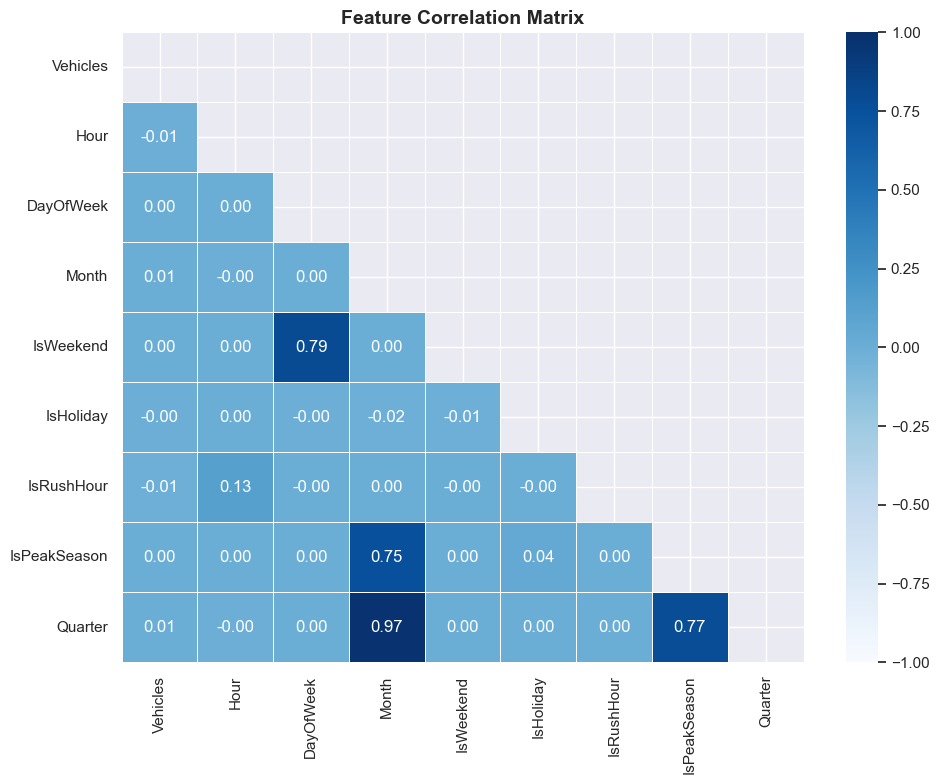

In [ ]:
num_cols = ['Vehicles','Hour','DayOfWeek','Month','IsWeekend','IsHoliday',
            'IsRushHour','IsPeakSeason','Quarter']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/graphs/correlation_heatmap.png', dpi=150)
plt.show()

##  EDA Summary

| Insight | Finding |
|---|---|
| Peak hours | 7–9 AM and 5–7 PM |
| Busiest junction | Junction 1 |
| Weekend reduction | ~20–30% less traffic |
| Holiday effect | Significantly lower volumes |
| Peak season | Oct–Dec (festive) |
| Key features | Hour, Junction, IsWeekend, IsHoliday |